# scSVC defines fine-grained subtypes of TAM cells

## Notebook Guide

**Purpose.** Reconstruct Monocyte iST-SVC profiles from Xenium spatial data and matched scRNA-seq reference.

**Inputs.** `../../raw_data/Real_application/P1CRC_Xenium.h5ad` and `adata_sc_all_reanno.h5ad`.

**Outputs.** `../../output/sc_SVC_case/P1CRC_Xenium/Monocyte/` with reconstructed expression, spatial SVCs, and cluster assignments.

**Reading order.**
1. Load spatial and reference data
2. Run TACCO global anchoring through revise-svc
3. Reconstruct Monocyte virtual cells
4. Select graph clustering resolution and save outputs

**Reproducibility note.** `revise` imports are standard package imports from the installed `revise-svc` distribution; this notebook does not modify `sys.path` to import the repository source tree.


## Minimum REVISE Input For This Case

To run this Xenium-style `iST` case, users only need two `AnnData` files. The spatial file should store a cell-by-gene count matrix in `st_adata.X`, gene names in `st_adata.var_names`, and two-dimensional cell coordinates in `st_adata.obsm["spatial"]`. The scRNA-seq reference should store a cell-by-gene count matrix in `sc_ref_adata.X`, gene names in `sc_ref_adata.var_names`, and broad cell-type labels in `sc_ref_adata.obs["Level1"]`. The two files only need to share genes by name; extra genes are ignored during reconstruction.

`Level2` labels are useful for downstream case analysis but are not the minimum required input. `all_cells_in_spot` is not needed for Xenium-style `iST` data because each row already represents a segmented cell.


In [1]:
import os
os.environ.setdefault("TQDM_DISABLE", "1")
os.environ.setdefault("TQDM_MININTERVAL", "60")

try:
    from IPython import get_ipython
    _ipython = get_ipython()
    if _ipython is not None:
        _ipython.run_line_magic("matplotlib", "inline")
except Exception:
    pass

save_adata_flag = False

output_dir = "../../output/sc_SVC_case/"
select_ct = "Mono_Macro"

alpha = 0.2

## Load Inputs

Read the spatial assay and reference scRNA-seq data, then align them to the case configuration.


In [2]:
patient_id = "P2CRC"
data_type = "Xenium"
cell_type_col = "Level1"

raw_data_path = "../../raw_data/Real_application"
raw_file_name = f"{raw_data_path}/{patient_id}_{data_type}.h5ad"
sc_file_name = f"{raw_data_path}/adata_sc_all_reanno.h5ad"

output_dir = f"{output_dir}/{patient_id}_{data_type}"

In [3]:
import os

output_dir = f"{output_dir}/{select_ct}"
os.makedirs(output_dir, exist_ok=True)

In [4]:
import scanpy as sc
import pandas as pd

adata_sp = sc.read(raw_file_name)
# adata_sp.obs['total_counts'] = adata_sp.X.sum(axis = 1)
adata_sp = adata_sp[adata_sp.obs['transcript_counts']>=60,:]
sc.pp.filter_genes(adata_sp, min_cells=100)

# adata_sp.obs = adata_sp.obs[['cell_id','x','y']]
# adata_sp.obs_names = adata_sp.obs['cell_id']

adata_sc = sc.read(sc_file_name)
adata_sc = adata_sc[adata_sc.obs['Patient'] == patient_id, :]
adata_sc.obs = adata_sc.obs[['Level1','Level2']]
sc.pp.filter_genes(adata_sc, min_cells=100)
adata_sc.obs['Level1'].replace({"Mono/Macro": "Mono_Macro"}, inplace=True)
adata_sc_raw = adata_sc.copy()

overlap_genes = adata_sp.var_names.intersection(adata_sc.var_names)
adata_sp = adata_sp[:, overlap_genes]

adata_sp

/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:283: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


/tmp/ipykernel_13654/2258595623.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adata_sc.obs['Level1'].replace({"Mono/Macro": "Mono_Macro"}, inplace=True)
/tmp/ipykernel_13654/2258595623.py:16: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_sc.obs['Level1'].replace({"Mono/Macro": "Mono_Macro"}, inplace=Tru

View of AnnData object with n_obs × n_vars = 242294 × 343
    obs: 'cell_id', 'x', 'y', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'x_old', 'y_old', 'Level1', 'max_score'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    obsm: 'Level1', 'spatial'

## Global Anchoring

Estimate cell-type probabilities with the installed `revise-svc` package before reconstruction.


In [5]:
from revise.backend.kernels import GlobalAnchoringKernel

# TACCO versions differ in the obsm key used for annotation probabilities.
# This keeps the installed revise-svc package while matching the legacy TACCO result semantics.
_ORIGINAL_GLOBAL_ANCHORING_RUN = GlobalAnchoringKernel.run

def _run_global_anchoring_tacco_compatible(self, st_adata, sc_ref_adata, **kwargs):
    if getattr(self, "mode", None) != "tacco":
        return _ORIGINAL_GLOBAL_ANCHORING_RUN(self, st_adata, sc_ref_adata, **kwargs)

    if "cell_type_col" in kwargs:
        self.cell_type_col = kwargs["cell_type_col"]

    import pandas as pd
    import tacco as tc

    st_adata = st_adata.copy()
    st_adata_raw = st_adata.copy()
    tc.tl.annotate(
        st_adata_raw,
        sc_ref_adata,
        self.cell_type_col,
        result_key=self.cell_type_col,
        multi_center=1,
        lamb=1e-3,
    )
    st_adata.obsm = st_adata_raw.obsm.copy()

    cell_type_ot = st_adata_raw.obsm.get("PD_of_ST_unit")
    if cell_type_ot is None:
        cell_type_ot = st_adata_raw.obsm.get(self.cell_type_col)
    if cell_type_ot is None:
        ref_categories = set(pd.Index(sc_ref_adata.obs[self.cell_type_col]).astype(str))
        for value in st_adata_raw.obsm.values():
            if hasattr(value, "columns") and ref_categories.intersection(pd.Index(value.columns).astype(str)):
                cell_type_ot = value
                break
    if cell_type_ot is None:
        raise KeyError(
            "Could not find TACCO annotation probabilities in AnnData.obsm "
            f"for cell_type_col={self.cell_type_col!r}; available keys: {list(st_adata_raw.obsm.keys())}"
        )
    return self._assign_result(cell_type_ot, st_adata)

GlobalAnchoringKernel.run = _run_global_anchoring_tacco_compatible
from revise.backend.runners.sc_svc_application import ScSVC
from revise.utils.logging import Logger
from revise.config.runner_conf import ApplicationScConf

config = ApplicationScConf(
    sample_name=patient_id,
    raw_data_path=raw_data_path,
    result_root_path=output_dir,
    cell_type_col=cell_type_col,
    confidence_col="Confidence",
    unknown_key="Unknown",
    st_file=f"{data_type}.h5ad",
    sc_ref_file=sc_file_name,
    annotate_mode="tacco"
)

logger = Logger(name=f"run.log", log_file=f'{output_dir}/application_sc.log').get_logger()
sc_svc = ScSVC(adata_sp, adata_sc, config, logger)
annotate_method = GlobalAnchoringKernel(config, logger)
adata_sp = annotate_method.run(sc_svc.st_adata, sc_svc.sc_ref_adata, cell_type_col = "Level1")


/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Starting preprocessing
Annotation profiles were not found in `reference.varm["Level1"]`. Constructing reference profiles with `tacco.preprocessing.construct_reference_profiles` and default arguments...


Finished preprocessing in 1.96 seconds.
Starting annotation of data with shape (242294, 343) and a reference of shape (30774, 343) using the following wrapped method:
+- platform normalization: platform_iterations=0, gene_keys=Level1, normalize_to=adata
   +- multi center: multi_center=1 multi_center_amplitudes=True
      +- bisection boost: bisections=4, bisection_divisor=3
         +- core: method=OT annotation_prior=None lamb=0.001
mean,std( rescaling(gene) )  26.94469404331636 31.808390564099085
bisection run on 1


bisection run on 0.6666666666666667


bisection run on 0.4444444444444444


bisection run on 0.2962962962962963


bisection run on 0.19753086419753085


bisection run on 0.09876543209876543


Finished annotation in 331.63 seconds.


/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/revise/backend/kernels/global_anchoring.py:114: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  st_adata.obs[self.cell_type_col].replace({np.nan: self.unknown_key}, inplace=True)


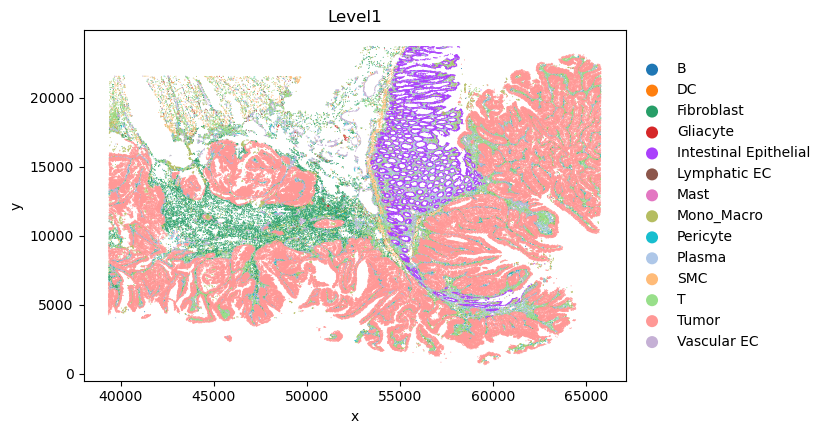

In [6]:
sc.pl.scatter(adata_sp, x="x", y="y", color="Level1", size=2)

In [7]:
print(select_ct)
ct_adata_sc = adata_sc[adata_sc.obs['Level1'] == select_ct]
ct_adata_sp = adata_sp[adata_sp.obs['Level1'] == select_ct]

Mono_Macro


In [8]:
subcell_type_col = "Level2"
ct_adata_sp = annotate_method.run(ct_adata_sp, ct_adata_sc, cell_type_col = subcell_type_col)

Starting preprocessing
Annotation profiles were not found in `reference.varm["Level2"]`. Constructing reference profiles with `tacco.preprocessing.construct_reference_profiles` and default arguments...


/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/tacco/preprocessing/_reference.py:112: ImplicitModificationWarning: Setting element `.varm['Level2']` of view, initializing view as actual.
  adata.varm[annotation_key] = profiles.reindex(index=adata.var.index)


Finished preprocessing in 0.23 seconds.
Starting annotation of data with shape (17605, 338) and a reference of shape (3505, 338) using the following wrapped method:
+- platform normalization: platform_iterations=0, gene_keys=Level2, normalize_to=adata
   +- multi center: multi_center=1 multi_center_amplitudes=True
      +- bisection boost: bisections=4, bisection_divisor=3
         +- core: method=OT annotation_prior=None lamb=0.001
mean,std( rescaling(gene) )  45.1557144919196 86.02549766779039
bisection run on 1


bisection run on 0.6666666666666667


bisection run on 0.4444444444444444


bisection run on 0.2962962962962963


bisection run on 0.19753086419753085


bisection run on 0.09876543209876543


Finished annotation in 9.77 seconds.


/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/revise/backend/kernels/global_anchoring.py:114: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  st_adata.obs[self.cell_type_col].replace({np.nan: self.unknown_key}, inplace=True)


## Cluster And Save Outputs

Evaluate clustering resolutions, select the working resolution, and save the final notebook-facing outputs.


In [9]:
from revise.backend.kernels import GraphClusterKernel

resolutions = [0.6, 0.7, 0.8]

graph_cluster = GraphClusterKernel(config, logger)
sc_SVC_adata, merge_df, best_res = graph_cluster.run(ct_adata_sp, resolutions, subcell_type_col)

sc_SVC_adata

/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:317: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


Preprocess: n_obs=17605 n_vars=100 n_hvg=100 n_pcs=30


Graph config: method=joint alpha=0.2 resolutions=[0.6, 0.7, 0.8] random_state=0
nn_graph_genes: shape=(17605, 17605) nnz=388348 sum=119220.859375
nn_graph_space: shape=(17605, 17605) nnz=105630 sum=105630.0
adjacency_graph: shape=(17605, 17605) nnz=488396 sum=116502.69490196992
diff_genes_space: nnz=487608 abs_sum=220075.3276979198 max_abs=1.0
diff_adj_genes: nnz=488396 abs_sum=44015.064050353576 max_abs=0.2
diff_adj_space: nnz=488396 abs_sum=176060.26366635365 max_abs=0.800000011920929


/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/revise/backend/kernels/graph_cluster.py:123: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


[2026-05-13 06:22:51] [INFO] [graph_cluster.py:142] Resolution 0.6: 7 clusters mean spatial score: 4.5717 0.8185...


[2026-05-13 06:23:01] [INFO] [graph_cluster.py:142] Resolution 0.7: 8 clusters mean spatial score: 3.7358 0.8017...


[2026-05-13 06:23:14] [INFO] [graph_cluster.py:142] Resolution 0.8: 9 clusters mean spatial score: 3.6260 0.8232...


Best resolution: 0.8


AnnData object with n_obs × n_vars = 17605 × 343
    obs: 'cell_id', 'x', 'y', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'x_old', 'y_old', 'Level1', 'max_score', 'Confidence', 'Level2', 'leiden_0.6', 'spatial_score_0.6', 'leiden_0.7', 'spatial_score_0.7', 'leiden_0.8', 'spatial_score_0.8'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'Level1_colors'
    obsm: 'Level1', 'spatial', 'Level2'

In [10]:
sc_SVC_adata.obs['SVC_cluster'] = sc_SVC_adata.obs[f'leiden_{best_res}']
sp_cluster_num = merge_df.loc[merge_df['resolution'] == best_res, 'cluster_num'].values[0]
sp_cluster_num

9

In [11]:
ct_adata_sc = annotate_method.run(ct_adata_sc, sc_SVC_adata, cell_type_col = "SVC_cluster")

Starting preprocessing
Annotation profiles were not found in `reference.varm["SVC_cluster"]`. Constructing reference profiles with `tacco.preprocessing.construct_reference_profiles` and default arguments...


Finished preprocessing in 0.18 seconds.
Starting annotation of data with shape (3505, 338) and a reference of shape (17605, 338) using the following wrapped method:
+- platform normalization: platform_iterations=0, gene_keys=SVC_cluster, normalize_to=adata
   +- multi center: multi_center=1 multi_center_amplitudes=True
      +- bisection boost: bisections=4, bisection_divisor=3
         +- core: method=OT annotation_prior=None lamb=0.001
mean,std( rescaling(gene) )  0.11634710855525651 0.36528448369917266


bisection run on 1


bisection run on 0.6666666666666667


bisection run on 0.4444444444444444


bisection run on 0.2962962962962963


bisection run on 0.19753086419753085


bisection run on 0.09876543209876543


Finished annotation in 3.06 seconds.


/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/revise/backend/kernels/global_anchoring.py:114: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  st_adata.obs[self.cell_type_col].replace({np.nan: self.unknown_key}, inplace=True)


In [12]:
if save_adata_flag:
    sc_SVC_adata.write(f"{output_dir}/sc_SVC_spatial.h5ad")
    ct_adata_sc.write(f"{output_dir}/sc_SVC_expr.h5ad")

print("Finish")

Finish
